In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

In [2]:
# 시스템에 설치된 폰트 중 한글 가능한 것 확인 및 적용
fonts = sorted({f.name for f in fm.fontManager.ttflist})
korean_candidates = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'AppleGothic']

found = next((candidate for candidate in korean_candidates if candidate in fonts), None)

if found is None:
    raise RuntimeError('사용 가능한 한글 폰트를 찾지 못했습니다. 설치된 폰트 목록을 확인하세요.')

plt.rcParams['font.family'] = found
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(font=found, rc={'axes.unicode_minus': False})

print("사용할 폰트:", found)
print()

# 전체 폰트 목록도 같이 출력 (후보가 없을 경우 직접 고르기 위해)
korean_fonts = [f for f in fonts if 'Gothic' in f or 'Nanum' in f or 'Malgun' in f]
print("한글 관련 폰트 목록:", korean_fonts)

사용할 폰트: Malgun Gothic

한글 관련 폰트 목록: ['Franklin Gothic Medium', 'MS Gothic', 'Malgun Gothic', 'NanumGothic', 'NanumMyeongjo', 'NanumSquare', 'NanumSquare_ac', 'Yu Gothic']


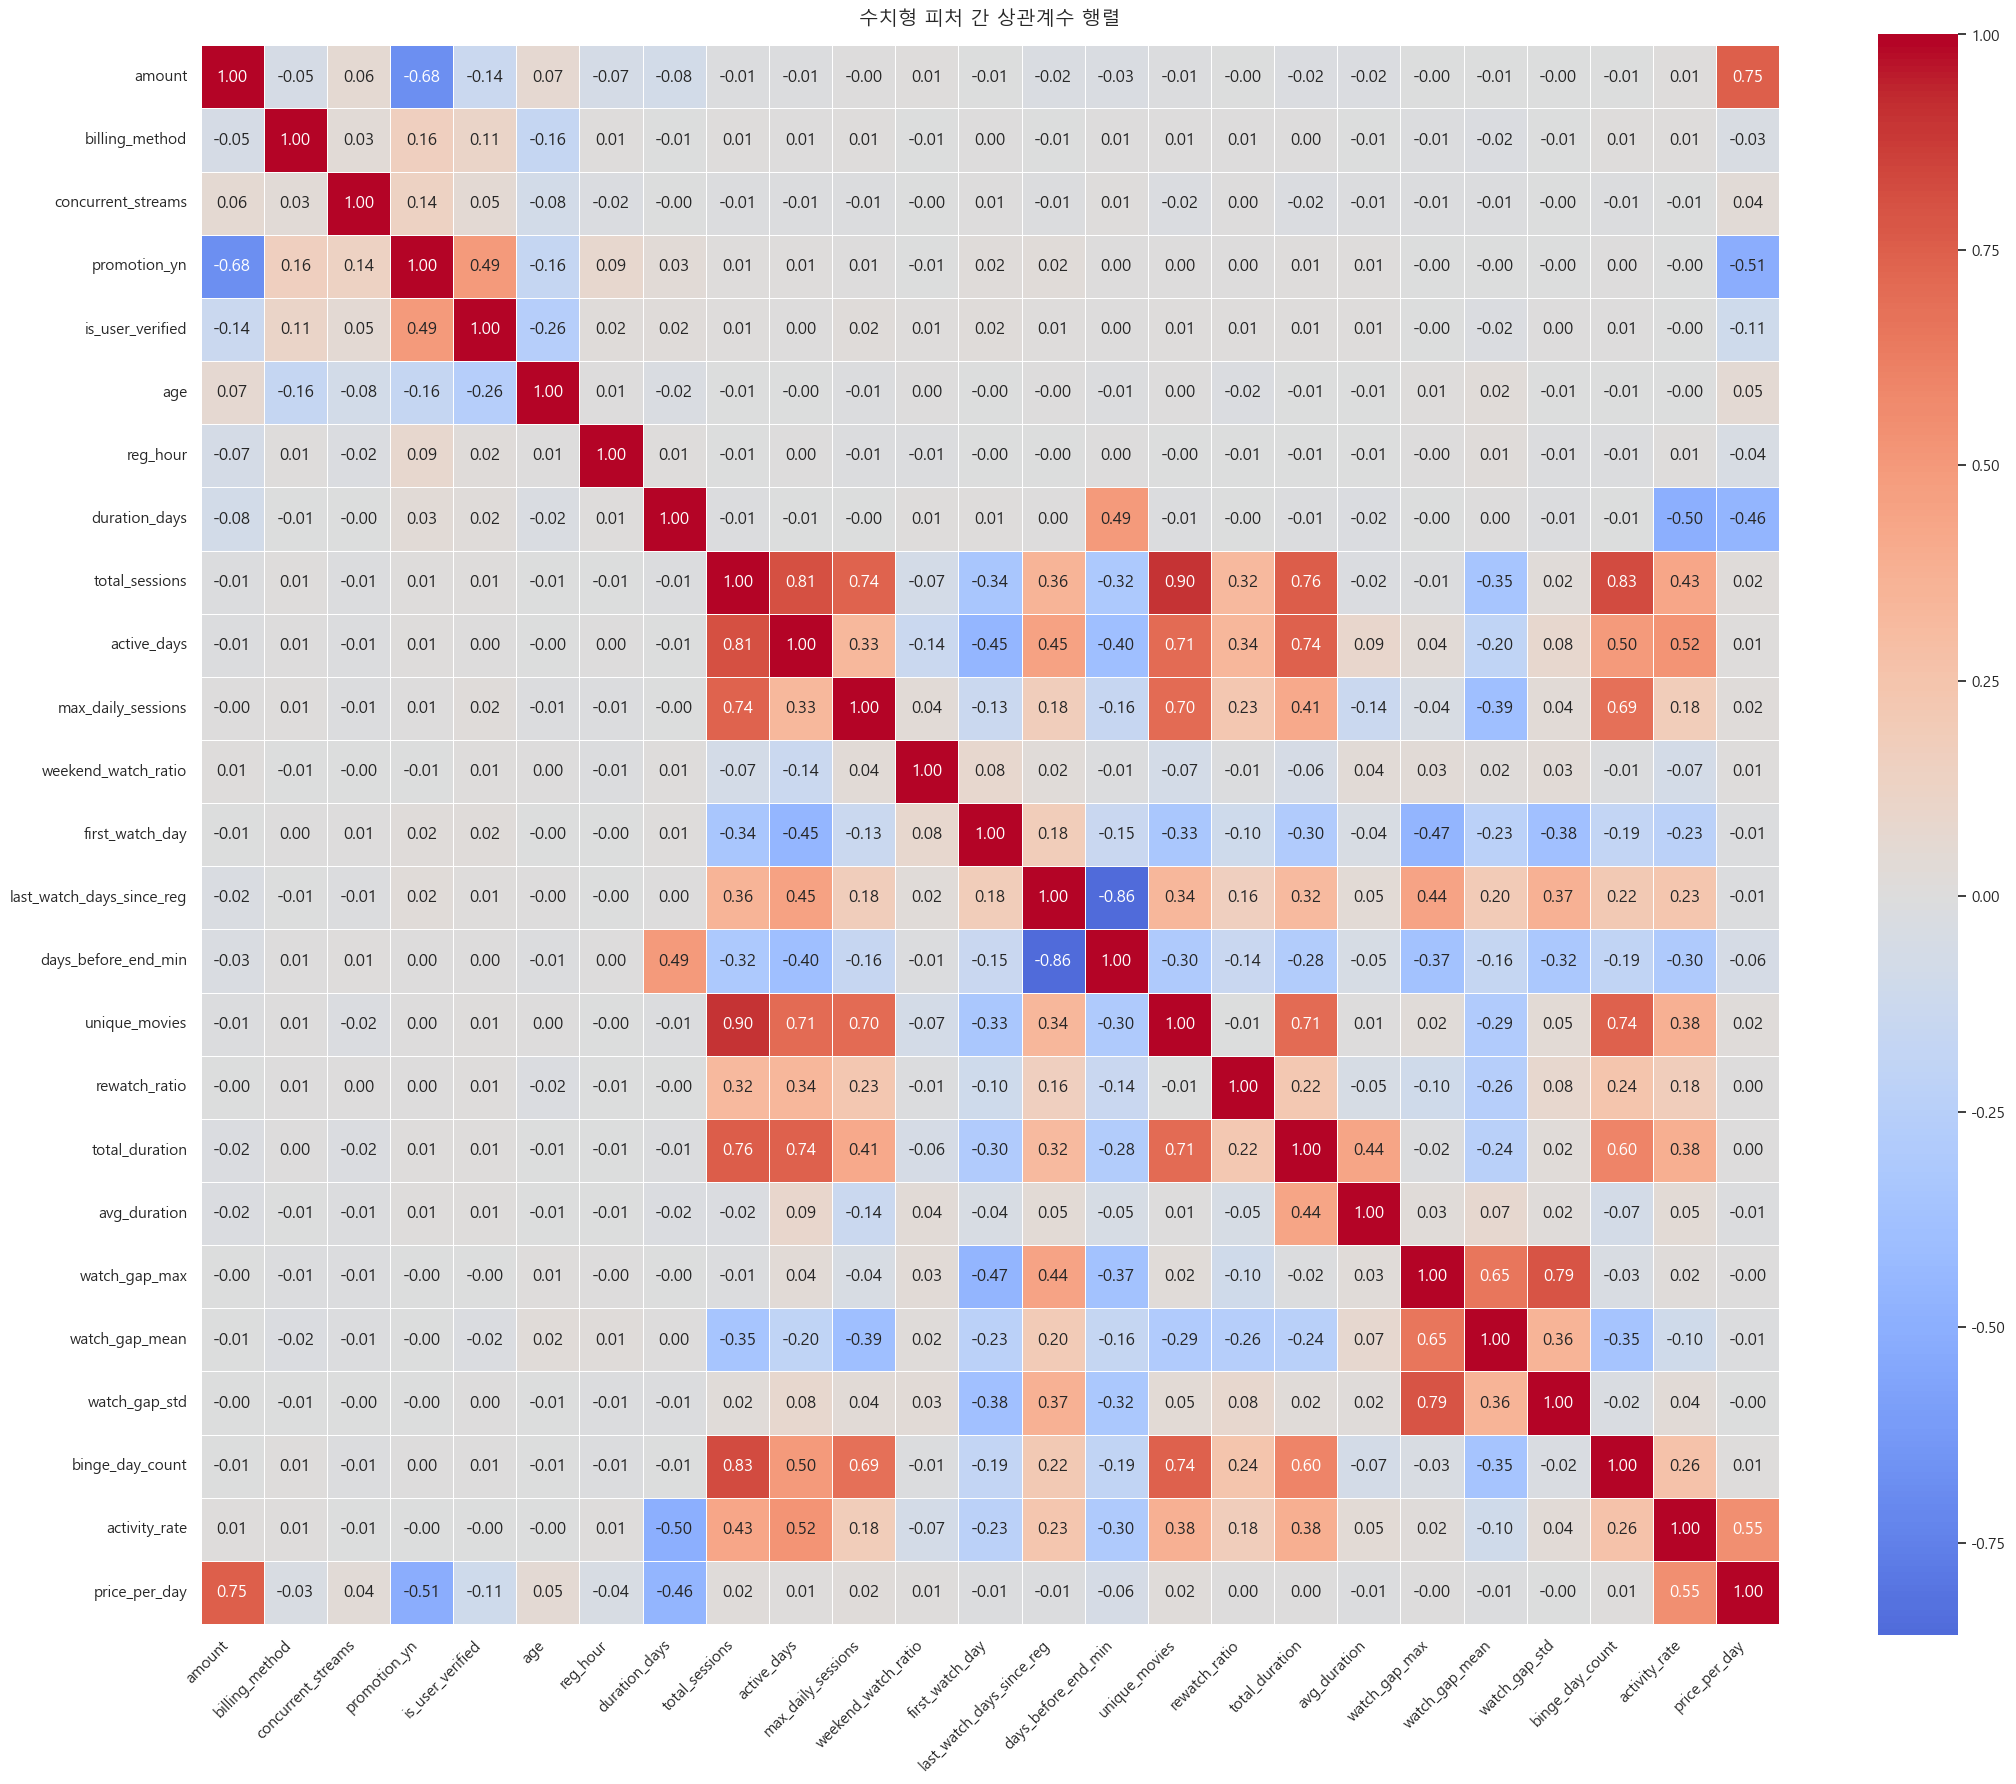


[ |상관계수| >= 0.7 인 쌍 ]
                     col1                col2      corr
           total_sessions       unique_movies  0.904556
           total_sessions     binge_day_count  0.825773
           total_sessions         active_days  0.809886
            watch_gap_max       watch_gap_std  0.794523
           total_sessions      total_duration  0.759360
                   amount       price_per_day  0.748637
            unique_movies     binge_day_count  0.744870
              active_days      total_duration  0.738989
           total_sessions  max_daily_sessions  0.735619
            unique_movies      total_duration  0.709658
              active_days       unique_movies  0.708167
       max_daily_sessions       unique_movies  0.704452
last_watch_days_since_reg days_before_end_min -0.857133


In [3]:
df = pd.read_excel(r"final_merged_user(단칼)_v2.xlsx")

# repurchase, is_churn_prevented → 타깃 변수 제외
# gender, product_cd, payment_device → 범주형 제외
# USER_KEY, USER_NUM, reg_date, end_date → 식별자/날짜 제외
numeric_cols = [
    # 원본 수치형
    'amount',
    'billing_method',
    'concurrent_streams',
    'promotion_yn',
    'is_user_verified',
    'age',
    'reg_hour',
    'duration_days',
    # 시청 행동
    'total_sessions',
    'active_days',
    'max_daily_sessions',
    'weekend_watch_ratio',
    'first_watch_day',
    'last_watch_days_since_reg',
    'days_before_end_min',
    # 콘텐츠 소비
    'unique_movies',
    'rewatch_ratio',
    'total_duration',
    'avg_duration',
    # 시청 간격
    'watch_gap_max',
    'watch_gap_mean',
    'watch_gap_std',
    # 기타
    'binge_day_count',
    'activity_rate',
    'price_per_day',
]

df_numeric = df[numeric_cols]

# 상관계수 행렬 계산
corr_matrix = df_numeric.corr()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(22, 18))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('수치형 피처 간 상관계수 행렬', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# |0.7| 이상 상관쌍 출력
print("\n[ |상관계수| >= 0.7 인 쌍 ]")
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['col1', 'col2', 'corr']
high_corr = high_corr[high_corr['corr'].abs() >= 0.7].sort_values('corr', ascending=False)
print(high_corr.to_string(index=False) if not high_corr.empty else "해당 없음")

> 수치형 피처 간 다중공선성 검토 (final_merged_user v2 기준, 25개 피처)

타깃 변수 (`repurchase`, `is_churn_prevented`), 범주형 (`gender`, `product_cd`, `payment_device`), 식별자/날짜 (`USER_KEY`, `USER_NUM`, `reg_date`, `end_date`)는 제외.

---

**[ |상관계수| >= 0.7 쌍 — 제거/대체 검토 필요 ]**

| col1 | col2 | corr | 판단 |
|---|---|---|---|
| `total_sessions` | `unique_movies` | 0.905 | 많이 볼수록 다양하게 봄 — 자연스러운 관계지만 중복 정보. `unique_movies` 제거 검토 |
| `last_watch_days_since_reg` | `days_before_end_min` | -0.857 | 구조적 반비례 (duration_days 고정 시 완전 동일). **`days_before_end_min` 유지, `last_watch_days_since_reg` 제거** |
| `total_sessions` | `binge_day_count` | 0.826 | 많이 볼수록 몰아본 날도 많음 — `binge_day_count` 제거 검토 |
| `total_sessions` | `active_days` | 0.810 | 많이 볼수록 시청 날도 많음 — `active_days`는 `activity_rate`로 대체 가능 |
| `watch_gap_max` | `watch_gap_std` | 0.795 | 최대 공백이 클수록 편차도 큼 — `watch_gap_std` 제거 검토 |
| `total_sessions` | `total_duration` | 0.759 | 많이 볼수록 총 시간도 많음 — `avg_duration`이 더 정제된 정보 |
| `amount` | `price_per_day` | 0.749 | price_per_day = amount / duration_days — **`price_per_day` 유지, `amount` 제거** |
| `unique_movies` | `binge_day_count` | 0.745 | 위와 동일 맥락 |
| `active_days` | `total_duration` | 0.739 | 위와 동일 맥락 |
| `total_sessions` | `max_daily_sessions` | 0.736 | 많이 볼수록 하루 최대도 높음 |
| `unique_movies` | `total_duration` | 0.710 | 위와 동일 맥락 |
| `active_days` | `unique_movies` | 0.708 | 위와 동일 맥락 |
| `max_daily_sessions` | `unique_movies` | 0.704 | 위와 동일 맥락 |

---

**[ 제거 권고 피처 ]**

`total_sessions`가 `unique_movies`, `active_days`, `total_duration`, `binge_day_count`, `max_daily_sessions`와 연쇄 상관.  
이 군에서 **`total_sessions` 하나만 남기거나**, 비율 피처(`activity_rate`, `rewatch_ratio`, `avg_duration`)로 대체하는 방향 권고.

| 제거 권고 | 유지 대안 | 이유 |
|---|---|---|
| `last_watch_days_since_reg` | `days_before_end_min` | 동일 정보, 이탈 예측에 더 직관적 |
| `amount` | `price_per_day` | 정규화된 지표가 더 유용 |
| `watch_gap_std` | `watch_gap_max` | max가 이탈 신호로 더 직접적 |
| `unique_movies`, `total_duration`, `binge_day_count`, `max_daily_sessions` | `total_sessions`, `avg_duration`, `activity_rate`, `rewatch_ratio` | `total_sessions`가 대표, 나머지는 비율형으로 대체 |

In [4]:
drop_cols = [
    # 구조적 중복 (파생변수로 대체됨)
    'amount',           # → price_per_day
    'active_days',      # → activity_rate
    'reg_date',         # datetime, ML 불가
    'end_date',         # datetime, ML 불가
    # 수식적 중복 (다른 피처 조합으로 완전 복원 가능)
    'last_watch_days_since_reg',  # = duration_days - days_before_end_min (duration_days 거의 상수)
    'unique_movies',              # = total_sessions × (1 - rewatch_ratio)
    'total_duration',             # = avg_duration × total_sessions
]

df_clean = df.drop(columns=drop_cols)

output_path = 'final_merged_user(단칼)_v3.xlsx'
df_clean.to_excel(output_path, index=False)
print(f"저장 완료: {output_path}")
print(f"Shape: {df_clean.shape}  ({df.shape[1]}개 → {df_clean.shape[1]}개 컬럼)")
print(f"\n남은 컬럼 ({df_clean.shape[1]}개):")
print(df_clean.columns.tolist())

저장 완료: final_merged_user(단칼)_v3.xlsx
Shape: (14433, 27)  (34개 → 27개 컬럼)

남은 컬럼 (27개):
['USER_KEY', 'USER_NUM', 'product_cd', 'billing_method', 'concurrent_streams', 'promotion_yn', 'is_churn_prevented', 'repurchase', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_hour', 'duration_days', 'total_sessions', 'max_daily_sessions', 'weekend_watch_ratio', 'first_watch_day', 'days_before_end_min', 'rewatch_ratio', 'avg_duration', 'watch_gap_max', 'watch_gap_mean', 'watch_gap_std', 'binge_day_count', 'activity_rate', 'price_per_day']


> 피처 정리 후 다중공선성 재검토 (v3 기준, 20개 피처)

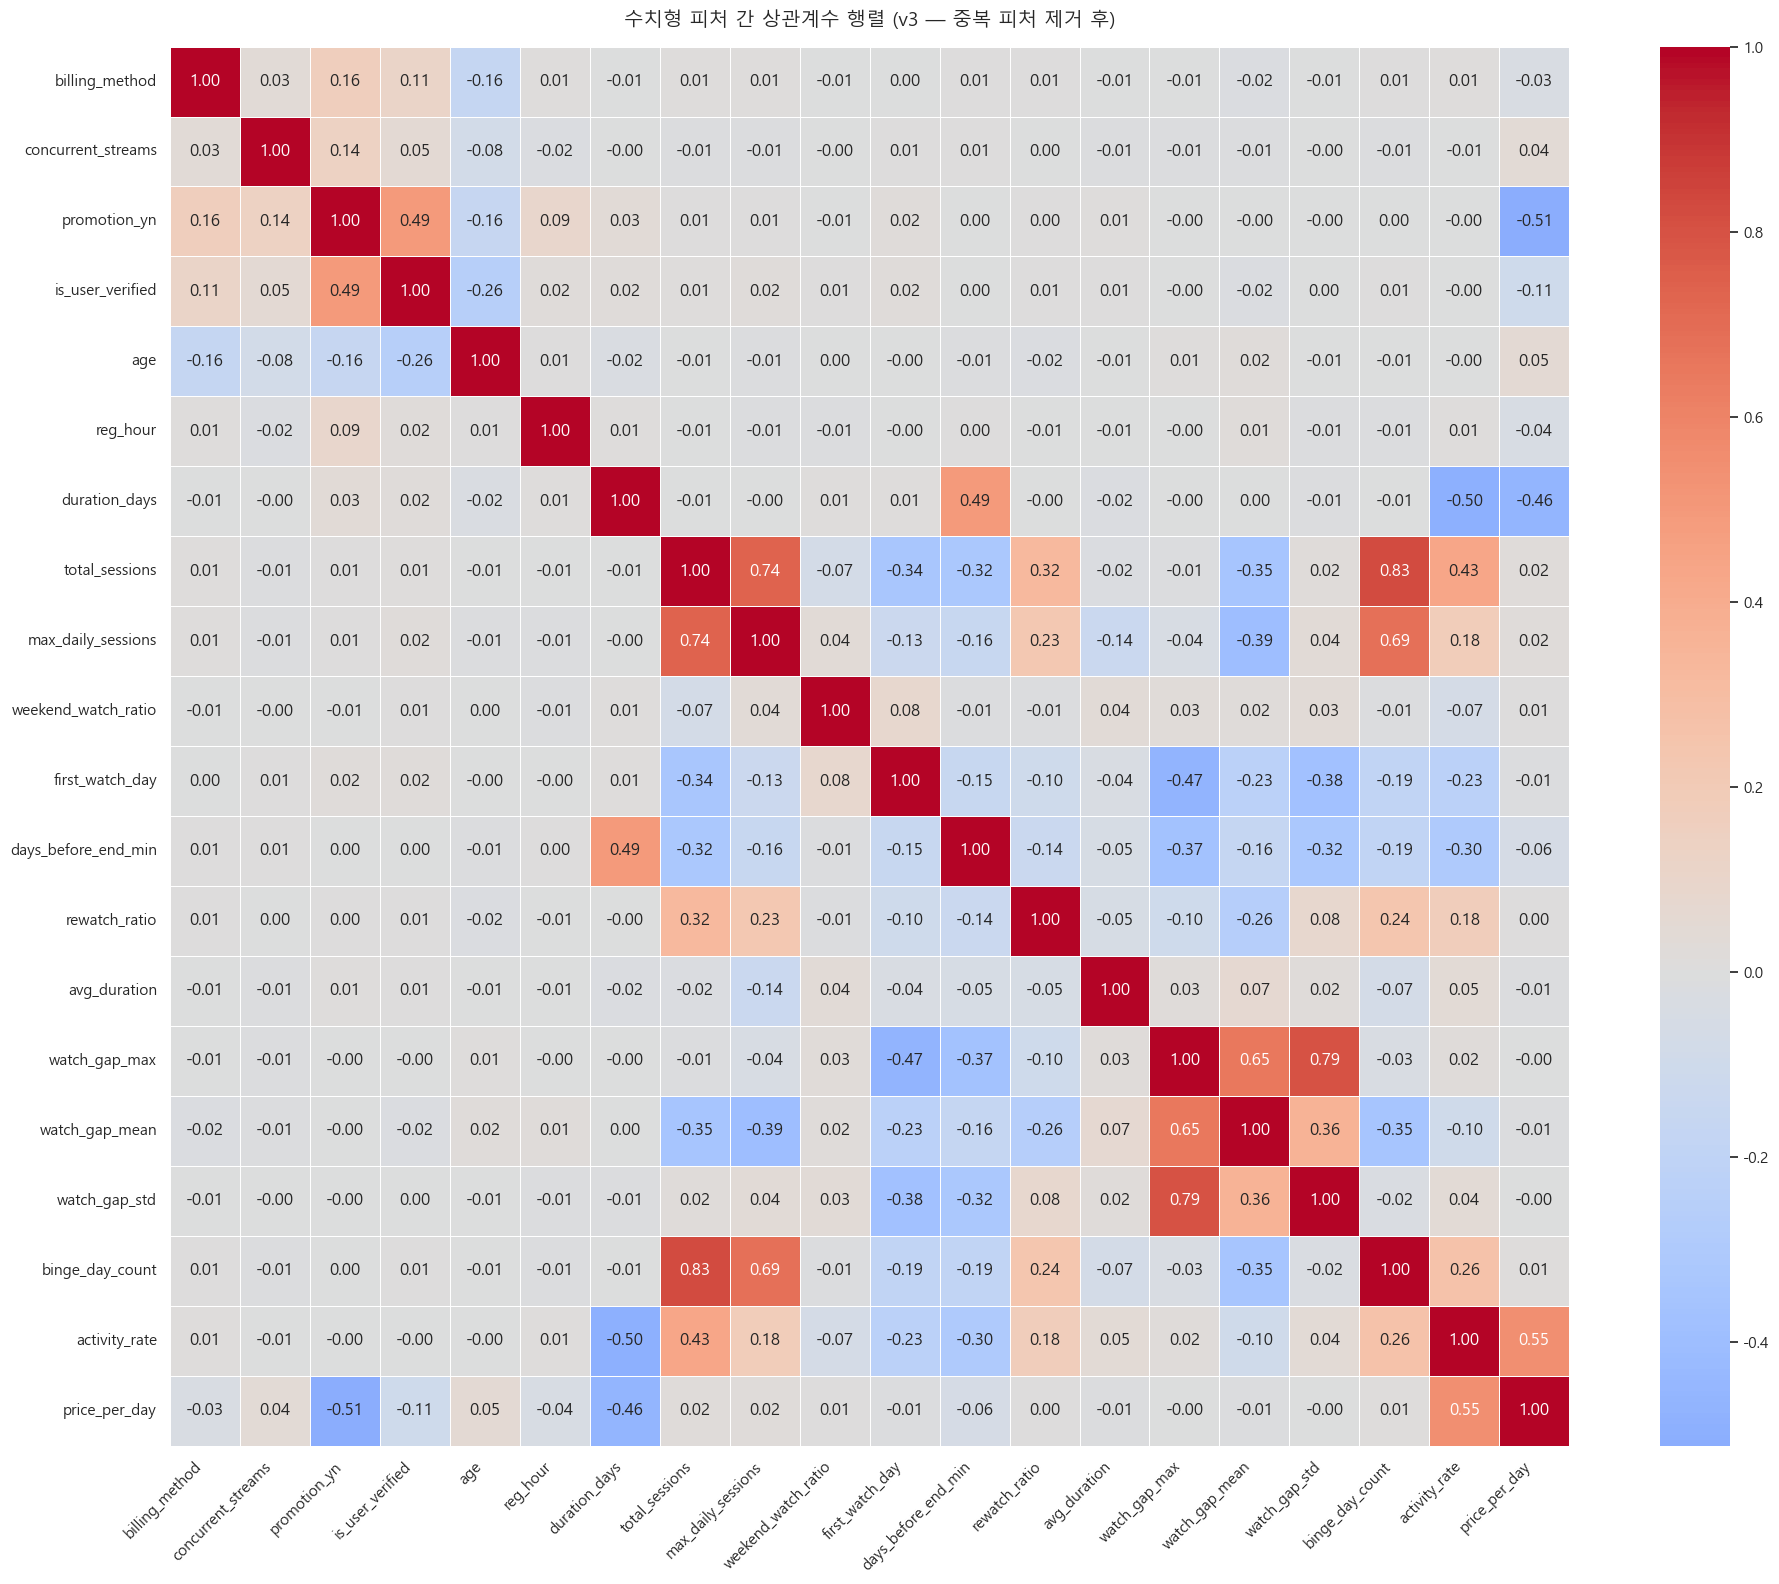


[ |상관계수| >= 0.7 인 쌍 ]
          col1               col2     corr
total_sessions    binge_day_count 0.825773
 watch_gap_max      watch_gap_std 0.794523
total_sessions max_daily_sessions 0.735619


In [5]:
df_v3 = pd.read_excel(r"final_merged_user(단칼)_v3.xlsx")

numeric_cols_v3 = [
    'billing_method', 'concurrent_streams', 'promotion_yn',
    'is_user_verified', 'age', 'reg_hour', 'duration_days',
    'total_sessions', 'max_daily_sessions', 'weekend_watch_ratio',
    'first_watch_day', 'days_before_end_min',
    'rewatch_ratio', 'avg_duration',
    'watch_gap_max', 'watch_gap_mean', 'watch_gap_std',
    'binge_day_count', 'activity_rate', 'price_per_day',
]

corr_v3 = df_v3[numeric_cols_v3].corr()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr_v3,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('수치형 피처 간 상관계수 행렬 (v3 — 중복 피처 제거 후)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n[ |상관계수| >= 0.7 인 쌍 ]")
high_corr_v3 = (
    corr_v3.where(np.triu(np.ones(corr_v3.shape), k=1).astype(bool))
    .stack().reset_index()
)
high_corr_v3.columns = ['col1', 'col2', 'corr']
high_corr_v3 = high_corr_v3[high_corr_v3['corr'].abs() >= 0.7].sort_values('corr', ascending=False)
print(high_corr_v3.to_string(index=False) if not high_corr_v3.empty else "해당 없음")

> v3 다중공선성 검토 결과

v2에서 13쌍(|corr|>=0.7) → v3에서 **3쌍으로 감소**.

| col1 | col2 | corr | 판단 |
|---|---|---|---|
| `total_sessions` | `binge_day_count` | 0.826 | 유지 — 총 시청량 vs 몰아본 날 빈도, 다른 개념 |
| `watch_gap_max` | `watch_gap_std` | 0.795 | 유지 — 최대 공백 vs 시청 규칙성, 다른 개념 |
| `total_sessions` | `max_daily_sessions` | 0.736 | 유지 — 총량 vs 하루 피크 강도, 다른 개념 |

세 쌍 모두 이전 분석에서 독립적인 정보를 담는다고 판단하여 유지 결정.  
추가 제거 없이 **v3 그대로 머신러닝 투입 가능**.